# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [3]:
17 

17

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [4]:
import pandas as pd

In [5]:
# Reading the dataset
port_bank_df = pd.read_csv('/Users/purohit2025/Downloads/module17_starter/data/bank-additional-full.csv',
                 sep=';')

In [6]:
port_bank_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [7]:
print(f"Rows: {port_bank_df.shape[0]}")
print(f"Columns: {port_bank_df.shape[1]}")

Rows: 41188
Columns: 21


In [8]:
port_bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [9]:
# Counting the missing (NaN) values in each feature
missing_values = port_bank_df.isnull().sum()
missing_values

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [10]:
# Displaying only features containing missing values
missing_values[missing_values > 0]

Series([], dtype: int64)

In [11]:
# Select categorical variables
categorical_columns = port_bank_df.select_dtypes(include='object').columns
categorical_columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [12]:
#creating a summary table
#counting 'unknown' values in each categorical feature

unknown_summary = pd.DataFrame({
    'Unknown Count': [
        (port_bank_df[column] == 'unknown').sum()
        for column in categorical_columns
    ]
}, index=categorical_columns)

unknown_summary

,Unknown Count
job,330
marital,80
education,1731
default,8597
housing,990
loan,990
contact,0
month,0
day_of_week,0
poutcome,0


In [13]:
# Displaying only features containing 'unknown' values and produceing a concise table highlighting only the relevant variables.

unknown_summary[unknown_summary['Unknown Count'] > 0]

,Unknown Count
job,330
marital,80
education,1731
default,8597
housing,990
loan,990


In [14]:
# Displaying data types of all variables
port_bank_df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

In [15]:
#The dataset (port_bank_df) contains no missing (NaN) values, as all 21 features have complete observations. 

In [16]:
# However, several categorical variables (job, marital, education, default, housing, and loan) contain the value "unknown", 
# which represents unavailable information and should be considered during preprocessing. 

In [17]:
#All features have appropriate data types (int64, float64, and object), so no data type coercion is required.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [18]:
port_bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [19]:
# Develop a machine learning model to predict whether a customer will subscribe to a term deposit. 

In [20]:
# Identify customers who are most likely to respond positively to a marketing campaign. 

In [21]:
# Improve the effectiveness of direct marketing campaigns by targeting potential customers. 

In [22]:
# Reduce unnecessary customer contacts and optimize marketing resources.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [23]:
# Data Preparation phase of CRISP-DM
# bank info features including age job, marital, education, default, housing, loan
# Selecting the bank client features
X = port_bank_df[['age','job','marital','education','default','housing','loan']]

# Selecting the target variable
y = port_bank_df['y']
# as the age is numeric and other 6 features are categorical
# One-Hot Encode categorical variables
X = pd.get_dummies(
    X,
    columns=['job','marital','education','default','housing','loan'],
    drop_first=True
)
# Encoding the targert variables yes and no to 1 and 0

y = y.map({'no': 0,
           'yes': 1})

In [24]:
# Displaying transformed features
X.head()

,age,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes
0,56,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,57,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2,37,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,40,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,56,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [25]:
# Displaying target values
y.head()

0    0
1    0
2    0
3    0
4    0
Name: y, dtype: int64

In [26]:
# Checking dimensions
print(X.shape)
print(y.shape)

(41188, 28)
(41188,)


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
# X: Predictor variables (the encoded bank client features).
# y: Target variable (0 = no, 1 = yes)
#Allocating 20% of the data for testing and 80% for training.

In [28]:
# Displaying to ensure the dimensions of the training sets
print(f"Training feature set: {X_train.shape}")

Training feature set: (32950, 28)


In [29]:
# Displaying to ensure the dimensions of the testing sets
print(f"Testing feature set:", X_test.shape)

Testing feature set: (8238, 28)


In [30]:
# Displaying to ensure the dimensions of the training sets
print(f"Training target set:", y_train.shape)

Training target set: (32950,)


In [31]:
# Displaying to ensure the dimensions of the testing sets
print(f"Testing target set:", y_test.shape)

Testing target set: (8238,)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [32]:
# baseline model should be the performance of a naive classifier that always predicts the majority class
# Calculating the baseline accuracy from the training target
baseline_accuracy = y_train.value_counts(normalize=True).max()
print(f"Baseline accuracy: {baseline_accuracy:0.2%}")

Baseline accuracy: 88.73%


In [34]:
# Displaying the class distribution in the training target
y_train.value_counts(normalize=True)

y
0    0.887344
1    0.112656
Name: proportion, dtype: float64

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Creating a pipeline to scale the features and fit Logistic Regression
logistic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000))
])

# Training the model
logistic_model.fit(X_train, y_train)

# Predicting the target values for the test set
y_pred = logistic_model.predict(X_test)

# Calculating the test accuracy
logistic_accuracy = accuracy_score(y_test, y_pred)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.2%}")

Logistic Regression Accuracy: 88.74%


In [36]:
#accuracy alone is insufficient for evaluating the model so 
#additional metrics such as precision, recall, and F1-score needs to be examined
#target is highly imbalanced as I am using only 7 bank client features

In [37]:
# Calculating the confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
conf_matrix = confusion_matrix(y_test, y_pred)

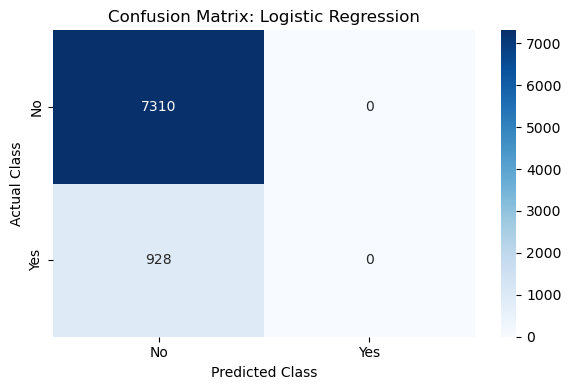

In [38]:
# Visualizing the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No', 'Yes'],
    yticklabels=['No', 'Yes']
)

plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import classification_report

# Displaying classification metrics for the basic Logistic Regression model
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['No', 'Yes'],
        zero_division=0
    )
)

              precision    recall  f1-score   support

          No       0.89      1.00      0.94      7310
         Yes       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238



In [40]:
#True Negatives (TN) = 7,310: correctly predicted non-subscribers
#False Positives (FP) = 0: no non-subscribers were incorrectly predicted as subscribers
#False Negatives (FN) = 928: every actual subscriber was incorrectly predicted as a non-subscriber
#True Positives (TP) = 0: the model identified no actual subscribers. 

### Problem 9: Score the Model

What is the accuracy of your model?

In [41]:
# Calculating the accuracy of the Logistic Regression model
logistic_accuracy = logistic_model.score(X_test, y_test)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.2%}")

Logistic Regression Accuracy: 88.74%


In [42]:
#basic Logistic Regression model achieved an accuracy of 88.74%
#however,this is approximately equal to the majority-class baseline
#so the accuracy does not represent a meaningful improvement

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [43]:
import warnings
from time import time
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [44]:
#creating classifiers using default settings
models = {
    'Logistic Regression': LogisticRegression(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'SVM': SVC()
}

In [45]:
# Creating an empty list to store model results
model_results = []

# Fit and evaluate each classifier
for model_name, model in models.items():

    # Record the start time
    start_time = time()

    # Train the model
    model.fit(X_train, y_train)

    # Calculate the training time
    train_time = time() - start_time

    # Calculate training and testing accuracy
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    # Store the results
    model_results.append({
        'Model': model_name,
        'Train Time': train_time,
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy
    })

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [49]:
## Presenting the model comparison in a DataFrame
model_comparison_df = pd.DataFrame(model_results)
model_comparison_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,14.993039,0.887344,0.887351
1,KNN,0.036111,0.891351,0.877519
2,Decision Tree,0.352951,0.917056,0.864045
3,SVM,81.313836,0.887344,0.887351


In [47]:
#LR and SVM achieved the highest test accuracy of 88.74%, 
#while KNN and DT achieved 87.75% and 86.36%, respectively.
#DT showed the largest gap between training and test accuracy, indicating overfitting, 
#while SVM required substantially more training time. 
#However, none of the default models meaningfully exceeded the 88.7% baseline,
#indicating that accuracy alone is insufficient for evaluating the business objective.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [48]:
# I plan to use F1-score for the positive (Yes) class as the GridSearchCV scoring metric  to improve the models
# F1 is likely to balance Precision and Recall
#Precision: Out of the customers predicted to subscribe, how many actually subscribed? 
#Recall: Out of all actual subscribers, how many did the model identify? 

In [ ]:
scoring='f1'
# tuning KNN
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance']
}

# tuning LR
logistic_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'class_weight': [None, 'balanced']
}

# Tuning DT
tree_params = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': [None, 'balanced']
}

# Tuning SVM
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'class_weight': [None, 'balanced']
}

In [ ]:
from sklearn.model_selection import GridSearchCV

# Creating the KNN grid search
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Fitting the grid search
knn_grid.fit(X_train, y_train)
print("Best KNN Parameters:", knn_grid.best_params_)
print(f"Best CV F1-Score: {knn_grid.best_score_:.4f}")

In [ ]:
best_knn = knn_grid.best_estimator_

y_pred_knn = best_knn.predict(X_test)

print(classification_report(y_test, y_pred_knn))

In [ ]:
# Creating LR grid search
logistic_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=logistic_params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# Fitting the grid search
logistic_grid.fit(X_train, y_train)

print("Best LR Parameters:", logistic_grid.best_params_)
print(f"Best CV F1-Score: {logistic_grid.best_score_:.4f}")

In [ ]:
best_lr = logistic_grid.best_estimator_

y_pred_lr = best_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr))

In [ ]:
# Creating the DT grid search
tree_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=tree_params,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print("Best DT Parameters:", tree_grid.best_params_)
print(f"Best CV F1-Score: {tree_grid.best_score_:.4f}")

In [ ]:
best_dt = tree_grid.best_estimator_

y_pred_dt = best_dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))

In [ ]:
# Creating the SVM grid search
svm_grid = GridSearchCV(
    estimator=SVC(),
    param_grid=svm_params,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

In [ ]:
best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test)

print(classification_report(y_test, y_pred_svm))

In [ ]:
print("Best SVM Parameters:", svm_grid.best_params_)
print(f"Best CV F1-Score: {svm_grid.best_score_:.4f}")

##### Questions